# Modeling

**Project:** Airbnb Pricing Analysis

**Team:** Jessie Dicker, Norma Arredondo

**Date:** April 19, 2026




## Table of Contents
1. Load Data
2. All Models - Default Parameters
3. Cross-Validation
4. Hyperparameter Tuning - GridSearch CV
5. Final Model Comparison
6. Save Best Model
7. Key Findings Summary

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load Data
Load the CSV files from Notebook 3.

In [2]:
# load data from preprocessing notebook
X_train_base = pd.read_csv('../data/processed/X_train.csv')
X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_train_base = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SCALE
X_train_standard = pd.read_csv('../data/modeling/X_train_final.csv')
X_test_standard = pd.read_csv('../data/modeling/x_test_final.csv')

print('Shapes\n')
print(f'Training (baseline): {X_train_base.shape}')
print(f'Training (with engineered features): {X_train.shape}')
print(f'Training (Standard): {X_train_standard.shape}')
print(f'Test (baseline):                 {X_test_base.shape}')
print(f'Test (with engineered features): {X_test.shape}')
print(f'Test (Scaled):                   {X_test_standard.shape}')

Shapes

Training (baseline): (38728, 10)
Training (with engineered features): (38728, 36)
Training (Standard): (38728, 36)
Test (baseline):                 (9682, 10)
Test (with engineered features): (9682, 36)
Test (Scaled):                   (9682, 36)


In [3]:
# Confirm Column Alignment
assert list(X_train.columns) == list(X_test.columns), \
    "Column mismatch between X_train and X_test"
assert list(X_train_standard.columns) == list(X_test_standard.columns), \
    "Column mismatch between X_train_standard and X_test_standard"

print("Column alignment confirmed for unscaled sets")
print("Column alignment confirmed for scaled sets")

Column alignment confirmed for unscaled sets
Column alignment confirmed for scaled sets


In [4]:
# Check Target Distribution and range
print('y_train distribution:')
print(y_train.describe().round(2))

print('\ny_test distribution:')
print(y_test.describe().round(2))

print('\nTarget Range:')
print(f"\ny_train range: ${int(y_train.min())} — ${int(y_train.max())}")
print(f"y_test range: ${int(y_test.min())} — ${int(y_test.max())}")

y_train distribution:
count    38728.00
mean       137.59
std        103.54
min         10.00
25%         69.00
50%        105.00
75%        175.00
max        799.00
Name: price, dtype: float64

y_test distribution:
count    9682.00
mean      137.52
std       104.72
min        10.00
25%        69.00
50%       103.00
75%       175.00
max       799.00
Name: price, dtype: float64

Target Range:

y_train range: $10 — $799
y_test range: $10 — $799


### Observations 


- **Shapes:**

  X_train: (38728, 36) and X_test: (9682, 36)

  
- **Target Range (after capping):**


  y_train range is between 10 and 799


- **Scaled vs. Unscaled for each model type:**


  Linear Regression -> Scaled and Unscaled Data 

  Ridge Regression -> Scaled Data

  Lasso Regression -> Scaled Data

  Decision Tree -> Unscaled Data

  Random Forest -> Unscaled Data


The shapes of X_train and X_test are the same as those in Notebook 3.


## 2. All Models - Default Parameters

Use different fitting models to train, predict, and print metrics. 

In [5]:
# store results
results = []

### Model 1: Linear Regression 
Both unscaled and scaled data are used

#### Data in Feature Engineering (Unscaled)

In [6]:
# import linear regression
from sklearn.linear_model import LinearRegression

lr_fe = LinearRegression()
lr_fe.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# linear regression (unscaled) train metrics
y_train_pred_lrfe = lr_fe.predict(X_train)

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train_lrfe = r2_score(y_train, y_train_pred_lrfe)
rmse_train_lrfe = np.sqrt(mean_squared_error(y_train, y_train_pred_lrfe))

print(f'No Scaling Linear Regression on train set: R² = {r2_train_lrfe:.4f}, RMSE = {rmse_train_lrfe:.4f}')


No Scaling Linear Regression on train set: R² = 0.4010, RMSE = 80.1404


In [9]:
# linear regression (unscaled) test metrics
y_pred_lrfe = lr_fe.predict(X_test)

In [10]:
r2_lrfe = r2_score(y_test, y_pred_lrfe)
rmse_lrfe = np.sqrt(mean_squared_error(y_test, y_pred_lrfe))

# store test metrics
results.append({'Model': 'No Scaling Linear Regression', 'Train R²': r2_train_lrfe, 'Test R²': r2_lrfe,
                'Train RMSE': rmse_train_lrfe, 'Test RMSE': rmse_lrfe})

print(f'No Scaling Linear Regression on test set: R² = {r2_lrfe:.4f}, RMSE = {rmse_lrfe:.4f}')

No Scaling Linear Regression on test set: R² = 0.3850, RMSE = 82.1216


#### Data in Feature Engineering with Scale

In [11]:
# use scale data
lr = LinearRegression()
lr.fit(X_train_standard, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# linear regression with scale train metrics
y_train_pred_lr = lr.predict(X_train_standard)

In [13]:
# train R² and RMSE
r2_train_lr = r2_score(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

print(f'Linear Regression with Scale on train set: R² = {r2_train_lr:.4f}, RMSE = {rmse_train_lr:.4f}')

Linear Regression with Scale on train set: R² = 0.4010, RMSE = 80.1404


In [14]:
# linear regression with scale test metrics
y_pred_lr = lr.predict(X_test_standard)

In [15]:
# test R² and RMSE
r2_lr  = r2_score(y_test, y_pred_lr )
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr ))

results.append({'Model': 'Scaling Linear Regression', 'Train R²': r2_train_lr, 'Test R²': r2_lr,
                'Train RMSE': rmse_train_lr, 'Test RMSE': rmse_lr})

print(f'Linear Regression with Scale on test set: R² = {r2_lr :.4f}, RMSE = {rmse_lr :.4f}')

Linear Regression with Scale on test set: R² = 0.3850, RMSE = 82.1216


#### Linear Regression Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Linear Regression | 0.4010 | 0.3850 | 80.1404 | 82.1216 |
| Linear Regression with Scale | 0.4010 | 0.3850 | 80.1404 | 82.1216 |

There is a 0.016 difference in the R² gap for the unscaled linear regression.

There is a 0.016 difference in the R² gap for the scaled linear regression.

Because the gap is not greater than 0.05, the scaled and unscaled linear regression does not appear to be overfitting. The R² for both models still appears to be low, suggesting that the model is not able to explain much of the variability in the data. Scaling the data did not improve model performance.

### Model 2: Ridge Regression
Scaled data only. L2 regularisation

#### Data in Feature Engineering with Scale

In [16]:
# import ridge regression
from sklearn.linear_model import  Ridge

# set default alpha=1.0
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_standard, y_train) # use scaled

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
# ridge regression - train metrics
y_train_pred_rg = ridge.predict(X_train_standard)
r2_train_rg = r2_score(y_train, y_train_pred_rg)
rmse_train_rg = np.sqrt(mean_squared_error(y_train, y_train_pred_rg))

print(f'Scaling Ridge Regression on train set: R² = {r2_train_rg:.4f}, RMSE = {rmse_train_rg:.4f}')

Scaling Ridge Regression on train set: R² = 0.4010, RMSE = 80.1405


In [18]:
# ridge regression - test metrics
y_pred_rg = ridge.predict(X_test_standard)
r2_rg = r2_score(y_test, y_pred_rg)
rmse_rg = np.sqrt(mean_squared_error(y_test, y_pred_rg))

results.append({'Model': 'Scaling Ridge Regression', 'Train R²': r2_train_rg, 'Test R²': r2_rg,
                'Train RMSE': rmse_train_rg, 'Test RMSE': rmse_rg})

print(f'Scaling Ridge Regression on test set: R² = {r2_rg:.4f}, RMSE = {rmse_rg:.4f}')

Scaling Ridge Regression on test set: R² = 0.3850, RMSE = 82.1209


#### Ridge Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Ridge Regression | 0.4010 | 0.3850 | 80.1405 | 82.1209 |


There is a 0.016 difference in the R² gap for the scaled ridge regression.

The scaled Ridge Regression achieved the same results as the Linear Regression models. Regularization did not improve model performance, likely because there is little multicollinearity or the penalty term is not strong enough. 

### Model 3: Lasso Regression
Scaled data only. L1 regularisation

#### Data in Feature Engineering with Scale

In [19]:
# import lasso regression
from sklearn.linear_model import  Lasso

# set default alpha = 0.01
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_standard, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [20]:
# lasso regression - train metrics
y_train_pred_ls = lasso.predict(X_train_standard)
r2_train_ls = r2_score(y_train, y_train_pred_ls)
rmse_train_ls = np.sqrt(mean_squared_error(y_train, y_train_pred_ls))

print(f'Scaling Lasso Regression on train set: R² = {r2_train_ls:.4f}, RMSE = {rmse_train_ls:.4f}')

Scaling Lasso Regression on train set: R² = 0.4008, RMSE = 80.1503


In [21]:
# lasso regression - test metrics
y_pred_ls = lasso.predict(X_test_standard)
r2_ls = r2_score(y_test, y_pred_ls)
rmse_ls = np.sqrt(mean_squared_error(y_test, y_pred_ls))

results.append({'Model': 'Scaling Lasso Regression', 'Train R²': r2_train_ls, 'Test R²': r2_ls, 
                'Train RMSE': rmse_train_ls, 'Test RMSE': rmse_ls})

print(f'Scaling Lasso Regression on test set: R² = {r2_ls:.4f}, RMSE = {rmse_ls:.4f}')


Scaling Lasso Regression on test set: R² = 0.3849, RMSE = 82.1288


In [22]:
# Check features Lasso zeroed out
zeroed = (lasso.coef_ == 0).sum()
total = len(lasso.coef_)
print(f'\nLasso zeroed out {zeroed} of {total} features ({zeroed/total*100:.1f}%)')

coef_df = pd.DataFrame({
    'Feature': X_train_standard.columns,
    'Coefficient': lasso.coef_
})

# sort by absolute value 
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coef_df[['Feature', 'Coefficient']])


Lasso zeroed out 1 of 36 features (2.8%)
                                          Feature  Coefficient
12                              room_type_encoded    85.169762
27                    neighbourhood_group_Midtown    65.827576
20         neighbourhood_group_Financial District    55.396733
34               neighbourhood_group_West Village    51.360186
2                                  minimum_nights   -36.465083
15                    neighbourhood_group_Chelsea    36.295768
29                 neighbourhood_group_Park Slope    34.455962
32            neighbourhood_group_Upper West Side    25.462365
7                              log_minimum_nights    23.708704
35               neighbourhood_group_Williamsburg    22.268555
9                                  is_new_listing    21.991631
19               neighbourhood_group_East Village    20.458194
28                      neighbourhood_group_Other    19.470588
33         neighbourhood_group_Washington Heights    19.363104
16           

In [23]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,No Scaling Linear Regression,0.4010,0.3850,80.1404,82.1216
1,Scaling Linear Regression,0.4010,0.3850,80.1404,82.1216
2,Scaling Ridge Regression,0.4010,0.3850,80.1405,82.1209
3,Scaling Lasso Regression,0.4008,0.3849,80.1503,82.1288


#### Lasso Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RMSE |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Lasso Regression | 0.4008 | 0.3849 | 80.1503 | 82.1288 |


There is a 0.0159 difference in the R² gap for the scaled lasso regression. Since the gap is less than 0.05, the model is not overfitting. It performed almost identically to Linear Regression and Ridge. 

Lasso zeroed out 1 of 36 features (`neighbourhood_group_Greenpoint`). The top 3 predictors of `price` were shown to be `room_type_encoded`, 
`neighbourhood_group_Midtown` and `neighbourhood_group_Financial District`. 

Because Linear Regression, Ridge, and Lasso all performed the same, regularization does not significantly improve the model. We need a more complex model to fit the relationship of the data. 

### Model 4: Decision Tree
Unscaled data only

#### Data in Feature Engineering  (Unscaled)

In [24]:
# import decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,4950
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
# decision tree - train metrics
y_train_pred_dt = dt.predict(X_train)
r2_train_dt = r2_score(y_train, y_train_pred_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))

print(f'No Scaling Decision Tree on train set: R² = {r2_train_dt:.4f}, RMSE = {rmse_train_dt:.4f}')

No Scaling Decision Tree on train set: R² = 0.5640, RMSE = 68.3688


In [26]:
# decision tree - test Metrics
y_pred_dt = dt.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

results.append({'Model': 'No Scaling Decision Tree', 'Train R²': r2_train_dt, 'Test R²': r2_dt, 
                'Train RMSE': rmse_train_dt, 'Test RMSE': rmse_dt})

print(f'No Scaling Decision Tree: R² = {r2_dt:.4f}, RMSE = {rmse_dt:.4f}')

No Scaling Decision Tree: R² = 0.3895, RMSE = 81.8189


#### Decision Tree Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Decision Tree | 0.5640 | 0.3895 | 68.3688 | 81.8189 |

There is a 0.1745 difference in the R² gap for the Decision Tree model. This is greater than 0.05, so the model is overfitting. Although the train performance improved significantly from the first three models, it did not imrprove on the test data due to its overfitting. 

Pruning or limiting tree depth may help improve test performance.

### Model 5: Random Forest
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [27]:
# import random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=4950, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# random forest - train metrics
y_train_pred_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

print(f'No Scaling Random Forest: R² = {r2_train_rf:.4f}, RMSE = {rmse_train_rf:.4f}')

No Scaling Random Forest: R² = 0.9276, RMSE = 27.8517


In [29]:
# random forest - test metrics
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

results.append({'Model': 'No Scaling Random Forest', 'Train R²': r2_train_rf, 'Test R²': r2_rf, 
                'Train RMSE': rmse_train_rf, 'Test RMSE': rmse_rf})

print(f'No Scaling Random Forest: R² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}')

No Scaling Random Forest: R² = 0.4745, RMSE = 75.9100


#### Random Forest Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Random Forest | 0.9276 | 0.4745 | 27.8517 | 75.9100 |


There is a 0.4531 difference in the R² gap for the unscaled random forest. This is significantly larger than 0.05, so the model is overfitting. However, the test performance improved significantly from the other models!

The overfitting may be helped by tuning the model further.

### Model 6: Gradient Boosting
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [30]:
# import gradient boosting 
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950)
gb.fit(X_train, y_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [31]:
# gradient boosting - train metrics
y_train_pred_gb = gb.predict(X_train)
r2_train_gb = r2_score(y_train, y_train_pred_gb)
rmse_train_gb = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))

print(f'No Scaling Gradient Boosting on train set: R² = {r2_train_gb:.4f}, RMSE = {rmse_train_gb:.4f}')


No Scaling Gradient Boosting on train set: R² = 0.5083, RMSE = 72.6028


In [32]:
# gradient boosting - test metric
y_pred_gb = gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

results.append({'Model': 'No Scaling Gradient Boosting', 'Train R²': r2_train_gb, 'Test R²': r2_gb, 
                'Train RMSE': rmse_train_gb, 'Test RMSE': rmse_gb})

print(f'No Scaling Gradient Boosting on test set: R² = {r2_gb:.4f}, RMSE = {rmse_gb:.4f}')


No Scaling Gradient Boosting on test set: R² = 0.4669, RMSE = 76.4553


#### Gradient Boosting Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Gradient Boosting | 0.5083 | 0.4669 | 72.6028 | 76.4553 |

There is a 0.0414 difference in the R² gap for the unscaled gradient boosting. Since this is below 0.05, the model is not overfitting.

Both the train and test performance improved over the other models, without the risk of overfitting! Although the train performance is slightly lower than the Random Forest model, it does not have the same problems overfitting, and the gap is much smaller. 


#### Comparison

In [33]:
# create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²',ascending=False)

results_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE
5,No Scaling Random Forest,0.927647,0.474498,27.851682,75.910025
6,No Scaling Gradient Boosting,0.508345,0.466922,72.602768,76.455276
4,No Scaling Decision Tree,0.564016,0.389503,68.368820,81.818922
2,Scaling Ridge Regression,0.400956,0.384988,80.140528,82.120919
0,No Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
1,Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
3,Scaling Lasso Regression,0.400810,0.384870,80.150300,82.128754


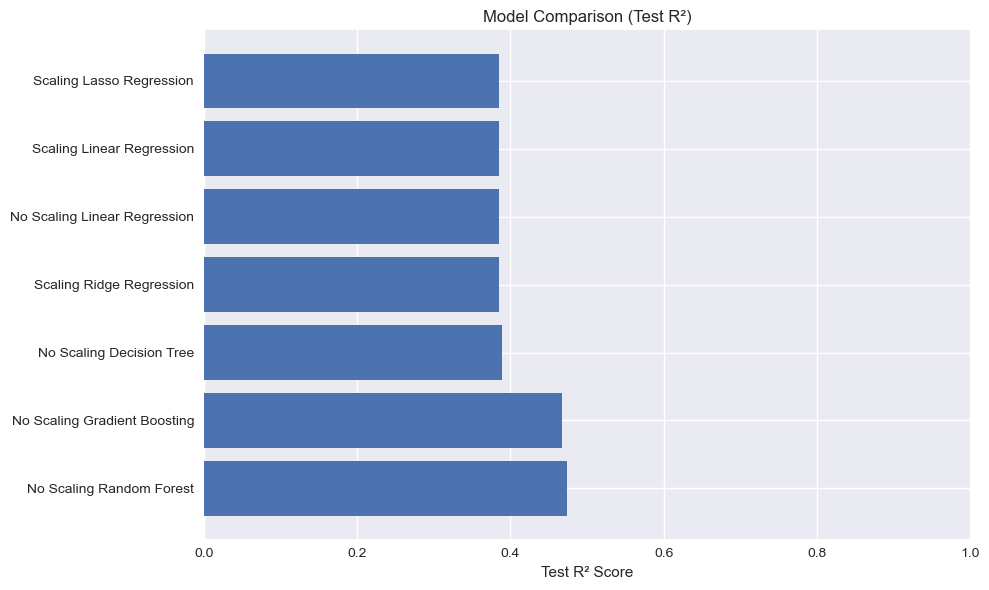

In [34]:
# barplot of model comparison by Test R²
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(results_df['Model'], results_df['Test R²'])

ax.set_xlabel('Test R² Score')
ax.set_title('Model Comparison (Test R²)')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()



In [35]:
results_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE
5,No Scaling Random Forest,0.927647,0.474498,27.851682,75.910025
6,No Scaling Gradient Boosting,0.508345,0.466922,72.602768,76.455276
4,No Scaling Decision Tree,0.564016,0.389503,68.368820,81.818922
2,Scaling Ridge Regression,0.400956,0.384988,80.140528,82.120919
0,No Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
1,Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
3,Scaling Lasso Regression,0.400810,0.384870,80.150300,82.128754


### Observations

**Best Performer:**
    Judging by Test R² alone, the No Scaling Random Forest was our highest performing model (Test R² = 0.474498). However, the gap between train and test performance for this model is extremely wide, suggesting overfitting. 
    The Gradient Boosting achieves adequate Train and Test R² with a much smaller gap (WITHOUT overfitting). Factoring in this information, this would be our best model. 
    
**Models with overfitting:** 
- Random Forest: severe overfitting (Train R² = 0.9276, Test R² = 0.4745, gap = 0.4531)
- Decision Tree: moderate overfitting (Train R²= 0.5640, Test R² = 0.3895, gap = 0.1745)

**Models to tune:**
- Ridge Regression
- Random Forest
- Gradient Boosting


## 3. Cross-Validation
Run 5-fold cross-validation on all models

In [36]:
# Cross-validation

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=4950)
cv_results = []


In [37]:
# Linear Regression (Unscaled)
lr_cv = LinearRegression()

scores_lr = cross_val_score(lr_cv, X_train, y_train, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Unscaled)','CV Mean R²': round(scores_lr.mean(), 4),'CV Std': round(scores_lr.std(), 4),
    'Fold 1': round(scores_lr[0], 4),'Fold 2': round(scores_lr[1], 4),'Fold 3': round(scores_lr[2], 4),'Fold 4': round(scores_lr[3], 4),
    'Fold 5': round(scores_lr[4], 4)})


print(f"Linear Regression (Unscaled)     mean={scores_lr.mean():.4f} std={scores_lr.std():.4f}  folds={np.round(scores_lr,3)}")


Linear Regression (Unscaled)     mean=0.4001 std=0.0086  folds=[0.408 0.395 0.399 0.411 0.388]


In [38]:
# Linear Regression (Scaled)
scores_lrs = cross_val_score(lr_cv, X_train_standard, y_train, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Scaled)','CV Mean R²': round(scores_lrs.mean(), 4),'CV Std': round(scores_lrs.std(), 4),
    'Fold 1': round(scores_lrs[0], 4),'Fold 2': round(scores_lrs[1], 4),'Fold 3': round(scores_lrs[2], 4),'Fold 4': round(scores_lrs[3], 4),
    'Fold 5': round(scores_lrs[4], 4)})


print(f"Linear Regression (Scaled)     mean={scores_lrs.mean():.4f} std={scores_lrs.std():.4f}  folds={np.round(scores_lrs,3)}")


Linear Regression (Scaled)     mean=0.4001 std=0.0086  folds=[0.408 0.395 0.399 0.411 0.388]


In [39]:
# Ridge Regression
ridge_cv = Ridge()

scores_rg = cross_val_score(ridge_cv, X_train_standard, y_train, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Ridge Regression','CV Mean R²': round(scores_rg.mean(), 4),'CV Std': round(scores_rg.std(), 4),
    'Fold 1': round(scores_rg[0], 4),'Fold 2': round(scores_rg[1], 4),'Fold 3': round(scores_rg[2], 4),'Fold 4': round(scores_rg[3], 4),
    'Fold 5': round(scores_rg[4], 4)})

print(f"Ridge Regression (Scaled)     mean={scores_rg.mean():.4f}  "
      f"std={scores_rg.std():.4f}  folds={np.round(scores_rg,3)}")

Ridge Regression (Scaled)     mean=0.4001  std=0.0086  folds=[0.408 0.394 0.399 0.411 0.388]


In [40]:
# Lasso Regression
lasso_cv = Lasso(alpha=0.01)

scores_ls = cross_val_score(lasso_cv, X_train_standard, y_train, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Lasso Regression','CV Mean R²': round(scores_ls.mean(), 4),'CV Std': round(scores_ls.std(), 4),
    'Fold 1': round(scores_ls[0], 4),'Fold 2': round(scores_ls[1], 4),'Fold 3': round(scores_ls[2], 4),'Fold 4': round(scores_ls[3], 4),
    'Fold 5': round(scores_ls[4], 4)})

print(f"Lasso Regression (Scaled)     mean={scores_ls.mean():.4f}  std={scores_ls.std():.4f}  folds={np.round(scores_ls,3)}")

Lasso Regression (Scaled)     mean=0.3999  std=0.0084  folds=[0.407 0.394 0.399 0.411 0.388]


In [41]:
# Decision Tree

dt_cv = DecisionTreeRegressor(max_depth=10, random_state=4950) 

scores_dt = cross_val_score(dt_cv, X_train, y_train, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Decision Tree','CV Mean R²': round(scores_dt.mean(), 4),'CV Std': round(scores_dt.std(), 4),
    'Fold 1': round(scores_dt[0], 4),'Fold 2': round(scores_dt[1], 4),'Fold 3': round(scores_dt[2], 4),'Fold 4': round(scores_dt[3], 4),
    'Fold 5': round(scores_dt[4], 4)})

print(f"Decision Tree (Unscaled)     mean={scores_dt.mean():.4f}  std={scores_dt.std():.4f}  folds={np.round(scores_dt,3)}")

Decision Tree (Unscaled)     mean=0.3831  std=0.0176  folds=[0.401 0.354 0.39  0.373 0.397]


In [42]:
# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=4950, n_jobs=-1)

scores_rf = cross_val_score(rf_cv, X_train, y_train, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Random Forest','CV Mean R²': round(scores_rf.mean(), 4),'CV Std': round(scores_rf.std(), 4),
    'Fold 1': round(scores_rf[0], 4),'Fold 2': round(scores_rf[1], 4),'Fold 3': round(scores_rf[2], 4),'Fold 4': round(scores_rf[3], 4),
    'Fold 5': round(scores_rf[4], 4)})

print(f"Random Forest (Unscaled)     mean={scores_rf.mean():.4f}  std={scores_rf.std():.4f}  folds={np.round(scores_rf,3)}")


Random Forest (Unscaled)     mean=0.4793  std=0.0122  folds=[0.499 0.462 0.476 0.486 0.474]


In [43]:
# Gradient Boosting
gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=4950)

scores_gb = cross_val_score(gb_cv, X_train, y_train, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Gradient Boosting','CV Mean R²': round(scores_gb.mean(), 4),'CV Std': round(scores_gb.std(), 4),
    'Fold 1': round(scores_gb[0], 4),'Fold 2': round(scores_gb[1], 4), 'Fold 3': round(scores_gb[2], 4),'Fold 4': round(scores_gb[3], 4),
    'Fold 5': round(scores_gb[4], 4)})

print(f"Gradient Boosting (Unscaled)     mean={scores_gb.mean():.4f}  std={scores_gb.std():.4f}  folds={np.round(scores_gb,3)}")


Gradient Boosting (Unscaled)     mean=0.4740  std=0.0108  folds=[0.488 0.457 0.475 0.482 0.467]


In [44]:
# Summary DataFrame
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=False).reset_index(drop=True)
print(cv_df.to_string(index=False))

                       Model  CV Mean R²  CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
               Random Forest      0.4793  0.0122  0.4987  0.4623  0.4757  0.4856  0.4743
           Gradient Boosting      0.4740  0.0108  0.4879  0.4574  0.4749  0.4821  0.4674
Linear Regression (Unscaled)      0.4001  0.0086  0.4077  0.3945  0.3992  0.4114  0.3876
  Linear Regression (Scaled)      0.4001  0.0086  0.4077  0.3945  0.3992  0.4114  0.3876
            Ridge Regression      0.4001  0.0086  0.4076  0.3945  0.3992  0.4114  0.3877
            Lasso Regression      0.3999  0.0084  0.4074  0.3943  0.3992  0.4110  0.3879
               Decision Tree      0.3831  0.0176  0.4015  0.3539  0.3903  0.3726  0.3971


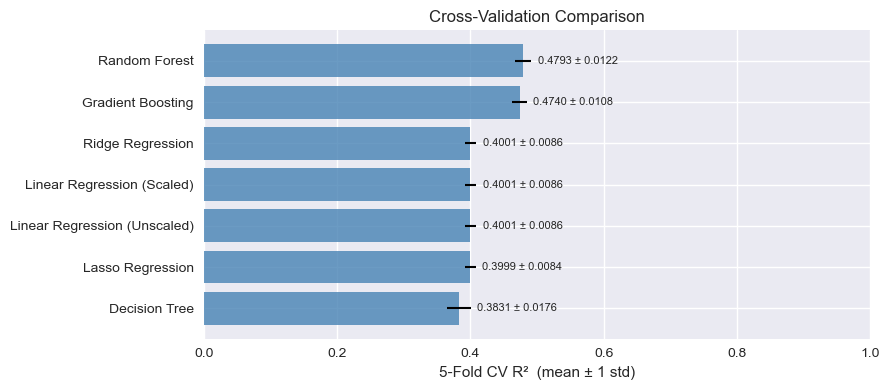

In [45]:
# Visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.01,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()


### Observations


**CV Mean and Test set results:**

The Random Forest model achieved the highest average cross-validated R² (0.4793), followed closely by Gradient Boosting (0.4740). Both models outperform linear, ridge, and lasso regression models, which all achieved similar performance around 0.40.

The low standard deviations across folds for Random Forest (0.0122) and Gradient Boosting (0.0108) indicate that these models are stable and consistent across different subsets.

Linear, Ridge, and Lasso regression models all performed identically, suggesting that regularization and scaling did not significantly improve performance. These models are likely underfitting and unable to capture the nonlinear relationships present in the data.

The Decision Tree model performed the worst overall and showed the highest variability across folds (std = 0.0176), likely overfitting and lacking generalization.

Overall, while Random Forest achieved the highest CV performance, Gradient Boosting provides the best balance between prediction accuracy and generalization, making it the best.


**Models with CV Std > 0.03:**

All seven models have CV Std below 0.03. There are no potentially unstable models. 


| Model | CV Std | 
| -------- | -------- |
| Decision Tree | 0.0176 |
| Random Forest | 0.0122 |
| Gradient Boosting | 0.0108 | 
| Ridge Regression | 0.0086 |
| Linear Regression (Unscaled) | 0.0086 | 
| Linear Regression (Scaled) | 0.0086 | 
| Lasso Regression | 0.0084 |


## 4. Hyperparameter Tuning - GridSearchCV

In [46]:
from sklearn.model_selection import GridSearchCV

### Ridge Regression Model Tuning

In [47]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_grid = GridSearchCV(Ridge(),
                         param_grid = param_grid,
                         cv=cv,
                         scoring='r2', n_jobs= -1)

ridge_grid.fit(X_train_standard, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [48]:
print(f'Best alpha: {ridge_grid.best_params_['alpha']}')
print(f'CV R² with best alpha: {ridge_grid.best_score_:.6f}')

Best alpha: 0.1
CV R² with best alpha: 0.400089


In [49]:
best_ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_standard, y_train,
                                cv=cv, scoring='r2', n_jobs=-1)
print(f"Best estimator CV mean ± std: {best_ridge_cv.mean():.4f} ± {best_ridge_cv.std():.4f}")

Best estimator CV mean ± std: 0.4001 ± 0.0086


In [50]:
ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[
    ['rank_test_score', 'param_alpha', 'mean_test_score', 'std_test_score']
]
ridge_cv_df.columns = ['rank', 'alpha', 'mean_R²', 'std_R²']
print(ridge_cv_df.sort_values('rank').head(5).round(6).to_string(index=False))

 rank  alpha  mean_R²   std_R²
    1  0.100 0.400089 0.008641
    2  0.010 0.400089 0.008643
    3  0.001 0.400089 0.008643
    4  1.000 0.400088 0.008616
    5 10.000 0.399975 0.008442


In [51]:
y_pred = ridge_grid.best_estimator_.predict(X_test_standard)

In [52]:
print('=== Ridge Regression (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Ridge Regression: R² = {r2:.6f}, RMSE = {rmse:.6f}')

=== Ridge Regression (Tuned) ===
Ridge Regression: R² = 0.384979, RMSE = 82.121485


In [53]:
# train vs test comparison
y_train_pred = ridge_grid.best_estimator_.predict(X_train_standard)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

results.append({'Model': 'Ridge Regression (tuned)', 'Train R²': r2_train, 'Test R²': r2, 
                'Train RMSE': rmse_train, 'Test RMSE': rmse})

print("\n=== Train vs Test Comparison (Ridge) ===")
print(f"Train R²: {r2_train:.6f}, RMSE: {rmse_train:.6f}")
print(f"Test  R²: {r2:.6f}, RMSE: {rmse:.6f}")


=== Train vs Test Comparison (Ridge) ===
Train R²: 0.400958, RMSE: 80.140426
Test  R²: 0.384979, RMSE: 82.121485


#### Tuned Ridge Regression Observations

After tuning Ridge Regression, the model achieved a train R² of 0.4010 and a test R² of 0.3850, with a difference of 0.016. The model is still not overfitting.

The tuned model produced nearly identical performance compared to the base Ridge model. Optimizing the regularization parameter did not significantly improve model performance.

Regularization is not a necessary factor in our problem, and the model is likely still underfitting. More complex models are needed to better capture the underlying relationships in the data.

### Random Forest Tuning (depth and feature sampling)

In [54]:
param_grid={
        'n_estimators': [100, 200],
        'max_depth':    [8, 12, 15, None],
        'max_features': ['sqrt', 0.5],
    }

rf_grid = GridSearchCV(RandomForestRegressor(random_state=4950, n_jobs=-1),
                      param_grid= param_grid,
                      cv=cv, scoring='r2', n_jobs=-1)

rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"CV R²:       {rf_grid.best_score_:.4f}")
print()

# Top 5 combinations
rf_cv_df = pd.DataFrame(rf_grid.cv_results_)[
    ['rank_test_score', 'param_n_estimators', 'param_max_depth', 'param_max_features',
     'mean_test_score', 'std_test_score']
]
rf_cv_df.columns = ['rank', 'n_estimators', 'max_depth', 'max_features', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(rf_cv_df.sort_values('rank').head(5).round(4).to_string(index=False))

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}
CV R²:       0.5002

Top 5 combinations:
 rank  n_estimators max_depth max_features  mean_R²  std_R²
    1           200        15         sqrt   0.5002  0.0120
    2           100        15         sqrt   0.4995  0.0116
    3           200        15          0.5   0.4982  0.0128
    4           200        12          0.5   0.4974  0.0106
    5           100        15          0.5   0.4965  0.0122


In [55]:
best_rf_cv = cross_val_score(
    rf_grid.best_estimator_, X_train, y_train,
    cv=cv, scoring='r2', n_jobs=-1
)
print(f"Best estimator CV mean ± std: {best_rf_cv.mean():.4f} ± {best_rf_cv.std():.4f}")

Best estimator CV mean ± std: 0.5002 ± 0.0120


In [56]:
print(rf_cv_df.round(6).to_string(index=False))

 rank  n_estimators max_depth max_features  mean_R²   std_R²
   16           100         8         sqrt 0.445702 0.008608
   15           200         8         sqrt 0.446684 0.008814
   14           100         8          0.5 0.474414 0.009863
   13           200         8          0.5 0.475087 0.009788
   12           100        12         sqrt 0.488679 0.011783
   10           200        12         sqrt 0.489810 0.011596
    6           100        12          0.5 0.496369 0.010129
    4           200        12          0.5 0.497432 0.010621
    2           100        15         sqrt 0.499526 0.011614
    1           200        15         sqrt 0.500173 0.011968
    5           100        15          0.5 0.496516 0.012247
    3           200        15          0.5 0.498222 0.012774
    8           100      None         sqrt 0.492966 0.011917
    7           200      None         sqrt 0.495204 0.012267
   11           100      None          0.5 0.489229 0.009745
    9           200     

In [57]:
y_pred = rf_grid.best_estimator_.predict(X_test)


print('=== Random Forest (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Random Forest: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Random Forest (Tuned) ===
Random Forest: R² = 0.4978, RMSE = 74.2075


In [58]:
# train vs test comparison
y_train_pred = rf_grid.best_estimator_.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

results.append({'Model': 'Random Forest (tuned)', 'Train R²': r2_train, 'Test R²': r2, 
                'Train RMSE': rmse_train, 'Test RMSE': rmse})

print("\n=== Train vs Test Comparison (Random Forest) ===")
print(f"Train R²: {r2_train:.6f}, RMSE: {rmse_train:.6f}")
print(f"Test  R²: {r2:.6f}, RMSE: {rmse:.6f}")


=== Train vs Test Comparison (Random Forest) ===
Train R²: 0.744192, RMSE: 52.369665
Test  R²: 0.497806, RMSE: 74.207490


#### Tuned Random Forest Observations

After tuning the Random Forest, the train R² decreased to 0.7442 while the test R² increased to 0.4978. The gap between training and test performance is approximately 0.2464, which indicates that the model is still overfitting but much less than the base model.

Compared to the original Random Forest, tuning significantly reduced overfitting by lowering the training performance while improving test performance. This demonstrates a better balance between bias and variance. However, some overfitting remains.

### Gradient Boosting Tuning (rate and depth)

In [59]:
param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5],
    }

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=4950),
                      param_grid=param_grid,
                       cv=cv, scoring='r2', n_jobs=-1)


gb_grid.fit(X_train, y_train)

print(f"Best params: {gb_grid.best_params_}")
print(f"CV R²:       {gb_grid.best_score_:.4f}")
print()

gb_cv_df = pd.DataFrame(gb_grid.cv_results_)[
    ['rank_test_score', 'param_n_estimators', 'param_learning_rate', 'param_max_depth',
     'mean_test_score', 'std_test_score']
]
gb_cv_df.columns = ['rank', 'n_estimators', 'learning_rate', 'max_depth', 'mean_R²', 'std_R²']
print(gb_cv_df.sort_values('rank').head(5).round(4).to_string(index=False))

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
CV R²:       0.4845

 rank  n_estimators  learning_rate  max_depth  mean_R²  std_R²
    1           200           0.05          5   0.4845  0.0131
    2           100           0.10          5   0.4827  0.0111
    3           200           0.10          5   0.4822  0.0122
    4           100           0.20          5   0.4787  0.0103
    5           100           0.05          5   0.4782  0.0120


In [60]:
best_gb_cv = cross_val_score(
    gb_grid.best_estimator_, X_train, y_train,
    cv=cv, scoring='r2', n_jobs=-1
)
print(f"Best estimator CV mean ± std: {best_gb_cv.mean():.4f} ± {best_gb_cv.std():.4f}")

Best estimator CV mean ± std: 0.4845 ± 0.0131


In [61]:
y_pred = gb_grid.best_estimator_.predict(X_test)


print('=== Gradient Boosting (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Gradient Boosting: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Gradient Boosting (Tuned) ===
Gradient Boosting: R² = 0.4762, RMSE = 75.7868


In [62]:
# train vs test comparison
best_gb = gb_grid.best_estimator_

y_train_pred = best_gb.predict(X_train)
y_test_pred = best_gb.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

results.append({'Model': 'Gradient Boosting (tuned)', 'Train R²': r2_train, 'Test R²': r2_test, 
                'Train RMSE': rmse_train, 'Test RMSE': rmse_test})

print("\n=== Train vs Test Comparison (Gradient Boosting) ===")
print("\nTrain R²:", round(r2_train, 4), "RMSE:", round(rmse_train, 4))
print("Test  R²:", round(r2_test, 4), "RMSE:", round(rmse_test, 4))



=== Train vs Test Comparison (Gradient Boosting) ===

Train R²: 0.5425 RMSE: 70.0357
Test  R²: 0.4762 RMSE: 75.7868


#### Tuned Gradient Boosting Observations

After tuning the Gradient Boosting, the train R² is 0.5425 and the test R² is 0.4762, resulting in a gap of 0.066. This indicates a small amount of overfitting, but significantly less than the decision tree and random forest models.

The model achieves strong predictive performance, with a test R² near the tuned random forest metric, while maintaining better generalization and significantly less overfitting. 

Compared to the linear, ridge, and lasso regression models, tuning Gradient Boosting provides a substantial improvement in performance, indicating that more flexible models are necessary for our problem.

Overall, Gradient Boosting offers the best balance between bias and variance, making it the most reliable model among those tested.

## 5. Final Model Comparison

### Default vs Tuned Model Comparison

In [63]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print('Model Comparison')
print('=' * 50)
print(results_df.to_string(index=False))

Model Comparison
                       Model  Train R²  Test R²  Train RMSE  Test RMSE
       Random Forest (tuned)  0.744192 0.497806   52.369665  74.207490
   Gradient Boosting (tuned)  0.542498 0.476203   70.035690  75.786761
    No Scaling Random Forest  0.927647 0.474498   27.851682  75.910025
No Scaling Gradient Boosting  0.508345 0.466922   72.602768  76.455276
    No Scaling Decision Tree  0.564016 0.389503   68.368820  81.818922
    Scaling Ridge Regression  0.400956 0.384988   80.140528  82.120919
    Ridge Regression (tuned)  0.400958 0.384979   80.140426  82.121485
No Scaling Linear Regression  0.400958 0.384978   80.140425  82.121561
   Scaling Linear Regression  0.400958 0.384978   80.140425  82.121561
    Scaling Lasso Regression  0.400810 0.384870   80.150300  82.128754


In [65]:
comparison_tune_scaling = pd.DataFrame([
    {'Model': 'Ridge Regression', 
     'Default': results_df.loc[results_df['Model']=='Scaling Ridge Regression', 'Test R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Ridge Regression (tuned)', 'Test R²'].values[0]},
    {'Model': 'Random Forest',
    'Default': results_df.loc[results_df['Model']=='No Scaling Random Forest', 'Test R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Random Forest (tuned)', 'Test R²'].values[0]},
    {'Model': 'Gradient Boosting',
    'Default': results_df.loc[results_df['Model']=='No Scaling Gradient Boosting', 'Test R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Gradient Boosting (tuned)', 'Test R²'].values[0]},
])
comparison_tune_scaling['Δ R²'] = (comparison_tune_scaling['Tuned'] - comparison_tune_scaling['Default']).round(4)
comparison_tune_scaling[['Default', 'Tuned']] = comparison_tune_scaling[['Default', 'Tuned']].round(4)
print(comparison_tune_scaling.to_string(index=False))

            Model  Default  Tuned    Δ R²
 Ridge Regression   0.3850 0.3850 -0.0000
    Random Forest   0.4745 0.4978  0.0233
Gradient Boosting   0.4669 0.4762  0.0093


In [67]:
ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_standard, y_train, cv=cv, scoring='r2', n_jobs=-1)
rf_cv    = cross_val_score(rf_grid.best_estimator_,    X_train,     y_train, cv=cv, scoring='r2', n_jobs=-1)
gb_cv    = cross_val_score(gb_grid.best_estimator_,    X_train,     y_train, cv=cv, scoring='r2', n_jobs=-1)

ridge_row = results_df[results_df['Model'] == 'Ridge Regression (tuned)'].iloc[0]
rf_row    = results_df[results_df['Model'] == 'Random Forest (tuned)'].iloc[0]
gb_row    = results_df[results_df['Model'] == 'Gradient Boosting (tuned)'].iloc[0]

final_df = pd.DataFrame({
    'Model':      ['Ridge (tuned)', 'Random Forest (tuned)', 'Gradient Boosting (tuned)'],
    'CV R2 mean': [ridge_cv.mean(), rf_cv.mean(), gb_cv.mean()],
    'CV R2 std':  [ridge_cv.std(),  rf_cv.std(),  gb_cv.std()],
    'Test R2':    [ridge_row['Test R²'], rf_row['Test R²'], gb_row['Test R²']],
    'Test RMSE':  [ridge_row['Test RMSE'], rf_row['Test RMSE'], gb_row['Test RMSE']],
}).round(4).sort_values('Test R2', ascending=False)

print(final_df.to_string(index=False))

                    Model  CV R2 mean  CV R2 std  Test R2  Test RMSE
    Random Forest (tuned)      0.5002     0.0120   0.4978    74.2075
Gradient Boosting (tuned)      0.4845     0.0131   0.4762    75.7868
            Ridge (tuned)      0.4001     0.0086   0.3850    82.1215


#### Default vs Tuned Observations

| Model | Default | Tuned | Δ R² |
| ----- | ------- | ----- | --- |
| Ridge Regression | 0.3850 | 0.3850 | -0.0000 |
| Random Forest | 0.4745 | 0.4978 | 0.0233 |
| Gradient Boosting | 0.4669 | 0.4762 | 0.0093 |

Hyperparameter tuning had different effects across the three models. Ridge Regression showed no improvement, with identical performance before and after tuning (Δ R² = 0.0000). This indicates that regularization was not a factor and further confirms that the model is underfitting.

Random Forest experienced the largest improvement from tuning, with test R² increasing from 0.4745 to 0.4978 (Δ R² = +0.0233). This demonstrates that controlling model complexity helped reduce overfitting and improved generalization.

Gradient Boosting also benefited from tuning, with test R² increasing from 0.4669 to 0.4762 (Δ R² = +0.0093). While this is smaller than Random Forest, Gradient Boosting continues to provide strong performance with better generalization (and less overfitting).

Overall, tuning was most impactful for the tree-based models, particularly Random Forest. Linear models such as Ridge Regression showed no benefit. This reinforces that model flexibility, rather than regularization, is the key driver of performance in our problem.



### Best Model Selection

In [70]:
results_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE
8,Random Forest (tuned),0.744192,0.497806,52.369665,74.207490
9,Gradient Boosting (tuned),0.542498,0.476203,70.035690,75.786761
5,No Scaling Random Forest,0.927647,0.474498,27.851682,75.910025
6,No Scaling Gradient Boosting,0.508345,0.466922,72.602768,76.455276
4,No Scaling Decision Tree,0.564016,0.389503,68.368820,81.818922
2,Scaling Ridge Regression,0.400956,0.384988,80.140528,82.120919
7,Ridge Regression (tuned),0.400958,0.384979,80.140426,82.121485
0,No Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
1,Scaling Linear Regression,0.400958,0.384978,80.140425,82.121561
3,Scaling Lasso Regression,0.400810,0.384870,80.150300,82.128754


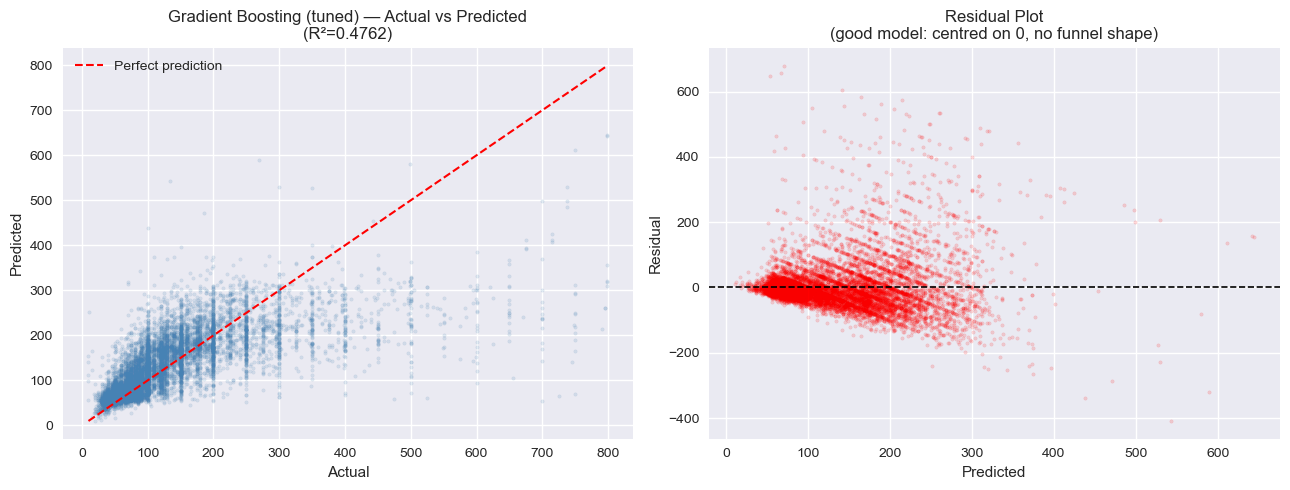

In [74]:
# We will choose the Gradient Boosting as the best model (due to RF overfitting)
best_model  = gb_grid.best_estimator_
best_name   =  'Gradient Boosting (tuned)'
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.15, s=6, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name} — Actual vs Predicted\n(R²={r2_score(y_test, y_pred_best):.4f})')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.15, s=6, color='red')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot\n(good model: centred on 0, no funnel shape)')

plt.tight_layout()
plt.show()

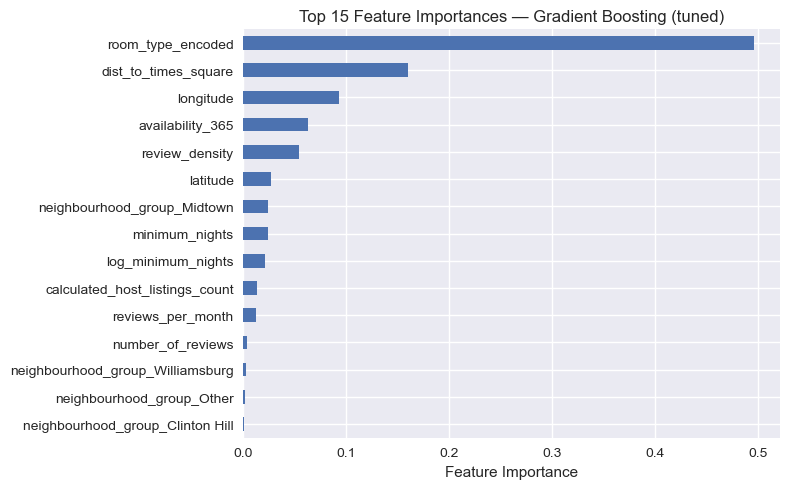

Top 5 most important features:
room_type_encoded       0.4963
dist_to_times_square    0.1598
longitude               0.0928
availability_365        0.0626
review_density          0.0543


In [75]:
importances = pd.Series(best_model.feature_importances_,index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

top_features.sort_values().plot.barh(figsize=(8,5))
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Feature Importances — {best_name}')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

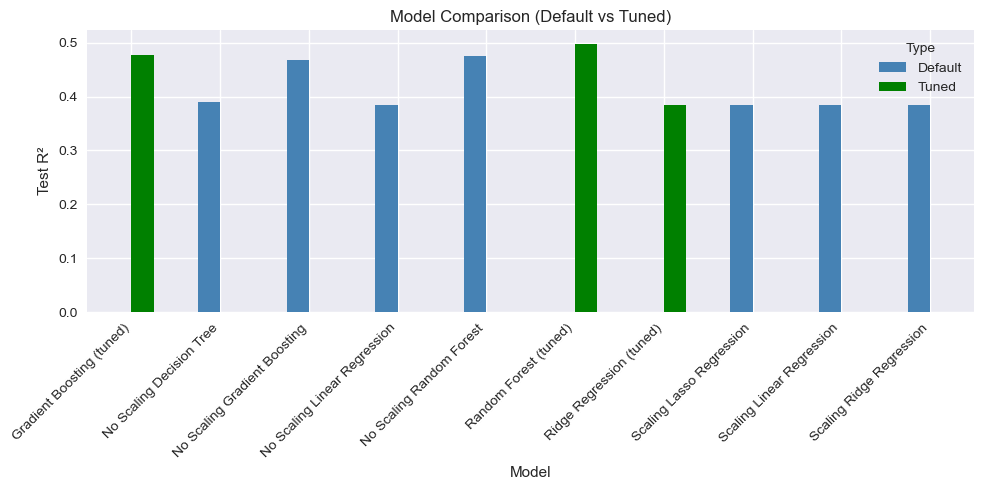

In [76]:
# plotting R² for all models (default and tuned models shown)
plot_df = results_df.copy()

plot_df['Type'] = plot_df['Model'].apply(
    lambda x: 'Tuned' if 'tuned' in x.lower() else 'Default'
)

plot_df['Base_Model'] = plot_df['Model'].str.replace(' \(tuned\)', '', regex=True)

pivot_df = plot_df.pivot_table(
    index='Model',
    columns='Type',
    values='Test R²',
    aggfunc='first'
)

pivot_df.plot(kind='bar', figsize=(10,5), color=['steelblue', 'green'])
plt.ylabel('Test R²')
plt.title('Model Comparison (Default vs Tuned)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Best Model Selection

Among all models, **Gradient Boosting (tuned)** is selected as the best overall model.

While the tuned Random Forest achieved the highest test R² (0.4978), it had substantial overfitting, as indicated by the large gap between training (0.7442) and test (0.4978) performance. This suggests that the model is capturing noise in the training data and may not generalize as reliably to new data.

In contrast, the tuned Gradient Boosting model achieved a slightly lower test R² (0.4762) but demonstrated much better generalization, with a much smaller gap between training (0.5425) and test (0.4762) performance. This indicates a more balanced model that effectively captures underlying patterns without overfitting.

Additionally, Gradient Boosting consistently outperformed all linear models (Linear, Ridge, and Lasso), which showed significantly lower R² values (~0.38). It also performed better than the Decision Tree model, which suffered from both lower performance and higher variance.

The Actual vs. Predicted plot shows that predictions generally follow the trend, although the model tends to underestimate higher price values. This suggests that while the model captures overall patterns well, it struggles with extreme values in the target variable. The residual plot is centered around zero, indicating no major bias in predictions. However, there is some spread in residuals as predicted values increase, suggesting less accuracy for higher-priced listings.

**Top 5 Most Important Features:**
- `room_type_encoded` (0.4963)
- `dist_to_times_square` (0.1598)
- `longitude` (0.0928)
- `availability_365` (0.0626)
- `review_density` (0.0543)

These results indicate that both AirBNB rental characteristics and location play a role in determining price.

Overall, Gradient Boosting provides the best balance between bias and variance, making it the most reliable and robust model for predicting `price` in the AirBnB data analysis.

## 6. Save Best Model


In [77]:
# Save the best model

import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f"Model : {type(best_model).__name__}")
print(f"Params: {rf_grid.best_params_}")
print(f"Test R2: {r2_score(y_test, y_pred_best):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")

Saved:  ../models/best_model.pkl
Model : GradientBoostingRegressor
Params: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}
Test R2: 0.4762
Test RMSE: 76


In [78]:
# test the saved model on first 5 samples
import pickle

with open('../models/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Loaded model type:", type(loaded_model).__name__)
print("Predictions for first 5 test rows:")
print(loaded_model.predict(X_test.head(5)))

Loaded model type: GradientBoostingRegressor
Predictions for first 5 test rows:
[119.3357032  176.68039869 140.54075763 173.4226804  282.35676866]


## Key Findings Summary

#### Key Findings Summary

1. ***Linear, Ridge, and Lasso*** regression models all achieved similar performance (R² = 0.40), indicating underfitting and an inability to capture non-linear relationships in the AirBnB data.

2. ***Tree-based models*** significantly imrpoved performance, with **Random Forest** achieving the highest test R² (~0.498) and **Gradient Boosting** providing the best balance between accuracy and generalization (R² ≈ 0.476).

3. Hyperparameter tuning had ***little impact on linear models*** but ***improved tree-based models***, particularly the Random Forest (Δ R² = +0.0233), by reducing the overfitting and improving performance on the test set.

4. Feature importance analysis showed that `room_type_encoded` was the strongest predictor, followed by location-based features such as `dist_to_times_square` and `longitude`, indicating that ***both property type and location*** are key determining factors of price.

5. The performance of all models was somewhat limited, with the highest test R² was still less than 0.50. However, these results are ***consistent with other analyses of this dataset***. The AirBnB price is difficult to predict without further information. 